In [ ]:
import sys
sys.path.insert(0, '.')

import numpy as np

import matplotlib.pyplot as plt

from scipy import signal

import mne
from mne.decoding import CSP

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

import loadmat as lm

mne.set_log_level('error')

# 1 Data processing
## 1.1 Load data

In [ ]:
data = lm.loadmat('MIdata.mat')['data']

# 0 = no task, 1-4 = motor imagery class, NaN = trial to predict
sig = data['signal']        # (nbSamples, nbChannels)
t = data['timeVector']      # (nbSamples,)
labels = data['labels']     # (nbSamples,)

fs = int(round(1 / np.median(np.diff(t))))  # sampling rate in Hz

classes = {1: 'left hand', 2: 'right hand', 3: 'both hands', 4: 'feet'}

w = max(len(v) for v in classes.values()) + 3
print(f'{"signal:":<{w}}{sig.shape[0]} samples x {sig.shape[1]} channels')
print(f'{"fs:":<{w}}{fs} Hz')
for k, v in classes.items():
    print(f'{v + ":":<{w}}{np.isclose(k, labels).sum():>6} samples')
print(f'{"NaN:":<{w}}{np.isnan(labels).sum():>6} samples')


signal:      501760 samples x 26 channels
fs:          256 Hz
left hand:    46080 samples
right hand:   46080 samples
both hands:   46080 samples
feet:         46080 samples
NaN:          61440 samples


## 1.2 Trial extraction

In [ ]:
# We want the 7-30 Hz band
band = (7, 30)

def bandpass_filter(sig, lowcut, highcut, fs, order=4):
    sos = signal.butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, sig, axis=0)

# Filter to the band containing alpha & beta waves
sig_filt = bandpass_filter(sig, *band, fs)

# Remove non-trial data (label == 0, NaN is unlabeled, but trial!)
idx = np.flatnonzero(~(labels == 0))
runs = np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)

# (nbTrials, nbChannels, nbSamples)
trials = np.stack([sig_filt[r] for r in runs]).transpose(0, 2, 1)
y = np.array([np.nan if np.isnan(labels[r]).all() else np.nanmax(labels[r]) for r in runs])

# Build training vectors
unlabelled = np.isnan(y)
X_train, y_train = trials[~unlabelled], y[~unlabelled].astype(int)
X_pred = trials[unlabelled]

print(f'trials: {len(trials)}   labelled: {len(X_train)}   to predict: {len(X_pred)}')
print(f'trial length: {trials.shape[2]} samples ({trials.shape[2] / fs:.1f} s)')
for c in sorted(classes):
    print(f'  {c} ({classes[c]}): {(y_train == c).sum()} trials')

trials: 160   labelled: 120   to predict: 40
trial length: 1536 samples (6.0 s)
  1 (left hand): 30 trials
  2 (right hand): 30 trials
  3 (both hands): 30 trials
  4 (feet): 30 trials


# 2 Feature extraction
## 2.1 CSP features

feature matrix: (120, 3)


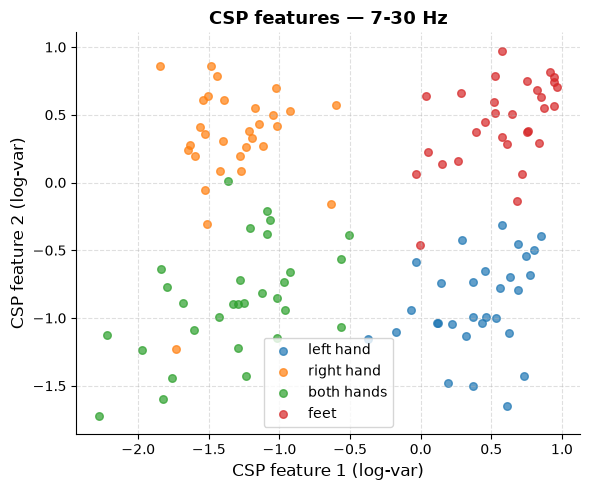

In [ ]:
# Common spacial pattern algorithm
csp = CSP(n_components=3, reg='ledoit_wolf', log=True, norm_trace=False)
features = csp.fit_transform(X_train, y_train)
print('feature matrix:', features.shape)

# Scatter-plot the CSP features of the four classes
fig, ax = plt.subplots(figsize=(6, 5))
for c in sorted(classes):
    m = y_train == c
    ax.scatter(features[m, 0], features[m, 1], s=30, alpha=0.7, label=classes[c])
ax.set_xlabel('CSP feature 1 (log-var)', fontsize=12)
ax.set_ylabel('CSP feature 2 (log-var)', fontsize=12)
ax.set_title(f'CSP features — {band[0]}-{band[1]} Hz', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 3 Classification
## 3.1 CSP + LDA cross-validation

In [ ]:
# Build pipeline: CSP features -> LDA for classification
clf = make_pipeline(
    CSP(n_components=3, reg='ledoit_wolf', log=True, norm_trace=False),
    LinearDiscriminantAnalysis())

# Validate with 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = cross_val_score(clf, X_train, y_train, cv=cv)

print(f'Accuracy: {accuracies.mean():.2%} +/- {accuracies.std():.2%}  (chance = {1 / len(classes):.0%})')
print('per fold:', np.round(accuracies, 3))

Accuracy: 96.67% +/- 3.12%  (chance = 25%)
per fold: [0.917 1.    1.    0.958 0.958]


## 3.2 Confusion matrix

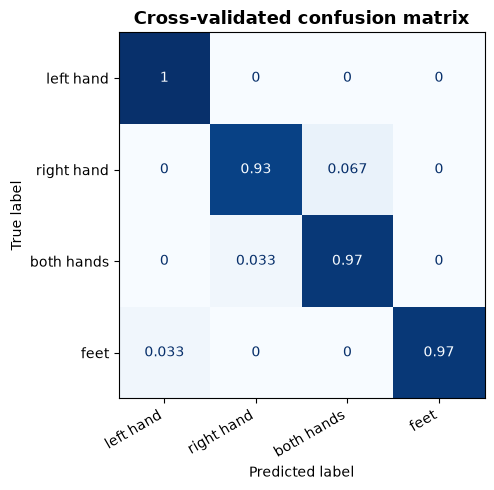

In [ ]:
# Predict labels
y_cv = cross_val_predict(clf, X_train, y_train, cv=cv)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_cv,
    labels=sorted(classes),
    display_labels=[classes[c] for c in sorted(classes)],
    cmap='Blues', normalize='true', colorbar=False, ax=ax)
ax.set_title('Cross-validated confusion matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# 4 Prediction
## 4.1 Unlabelled trials

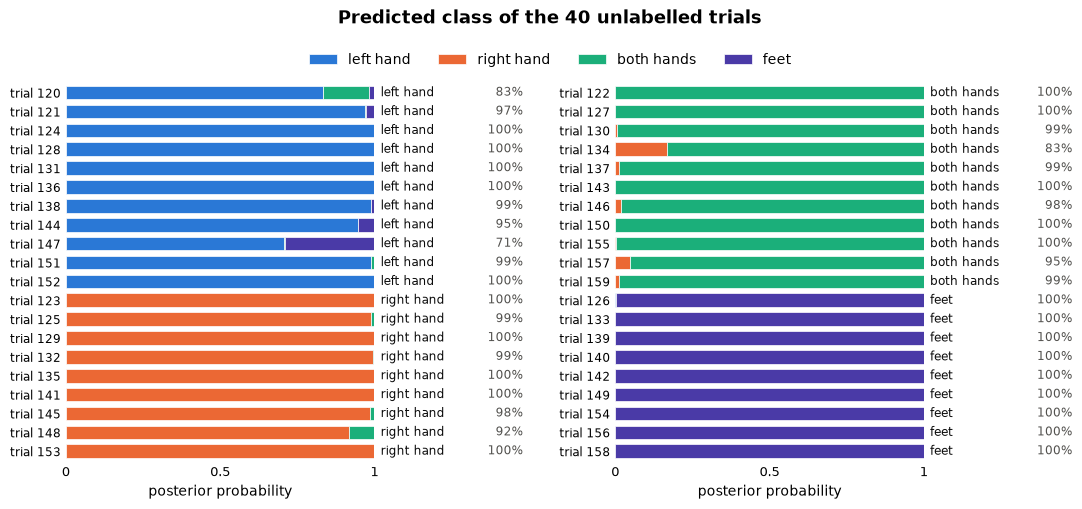

In [ ]:
# Train classifier pipeline & predict unlabeled trials
clf.fit(X_train, y_train)
pred = clf.predict(X_pred).astype(int)
# Also determine how sure LDA is about each trial
proba = clf.predict_proba(X_pred)

# Plot the confidence and class predictions per trial
col = {c: i for i, c in enumerate(clf.classes_)}
trial_ids = np.flatnonzero(unlabelled)
order = np.argsort(pred, kind='stable')

COLORS = {1: '#2a78d6', 2: '#eb6834', 3: '#1baf7a', 4: '#4a3aa7'}
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True)
half = int(np.ceil(len(order) / 2))
for ax, chunk in zip(axes, (order[:half], order[half:])):
    rows = np.arange(len(chunk))
    left = np.zeros(len(chunk))
    for c in sorted(classes):
        w = proba[chunk, col[c]]
        ax.barh(rows, w, left=left, height=0.72, color=COLORS[c],
                edgecolor='white', linewidth=0.5,
                label=classes[c] if ax is axes[0] else None)
        left += w
    for r, i in enumerate(chunk):
        ax.text(1.02, r, classes[pred[i]], va='center', fontsize=8.5, color='#0b0b0b')
        ax.text(1.48, r, f'{proba[i].max():.0%}', va='center', ha='right',
                fontsize=8.5, color='#52514e')
    ax.set_yticks(rows, [f'trial {trial_ids[i]}' for i in chunk], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_xticks([0, 0.5, 1], ['0', '0.5', '1'], fontsize=9)
    ax.set_xlabel('posterior probability', fontsize=10)
    ax.tick_params(length=0)
    ax.spines[:].set_visible(False)
    ax.margins(y=0.01)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=4, frameon=False, fontsize=10)
fig.suptitle(f'Predicted class of the {len(pred)} unlabelled trials',
             fontsize=13, fontweight='bold', y=0.98)
fig.subplots_adjust(left=0.06, right=0.84, wspace=0.78, top=0.84)
plt.show()

## 4.2 Predicted class distribution

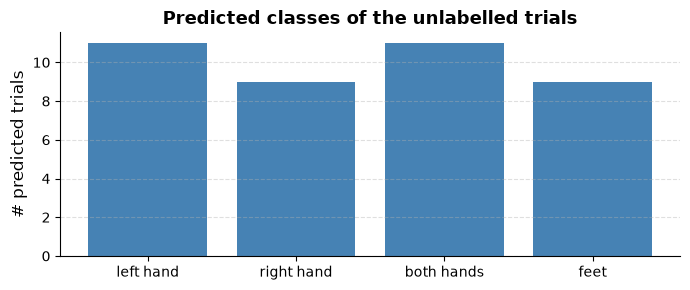

In [ ]:
counts = [int((pred == c).sum()) for c in sorted(classes)]

# Plot class frequencies
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([classes[c] for c in sorted(classes)], counts, color='steelblue')
ax.set_ylabel('# predicted trials', fontsize=12)
ax.set_title('Predicted classes of the unlabelled trials', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()